# CO2 Correlation Analysis - Chris Samuel

**Location:** LEO West, x=-1, y=4  
**Period:** 2024-07-10 12:30:00 to 2024-07-29 14:45:00 (15-min intervals)

## Sensors
- Air: sensor_id=1275, height=25cm
- Basalt 5cm: sensor_id=995
- Basalt 20cm: sensor_id=1011
- Basalt 50cm: sensor_id=1034

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.signal import correlate
from sklearn.decomposition import PCA
from statsmodels.graphics.gofplots import qqplot
import sys
from pathlib import Path

%matplotlib inline
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

# Configuration
IDEAL_START = pd.Timestamp('2024-07-10 12:30:00')
IDEAL_END = pd.Timestamp('2024-07-29 14:45:00')
IDEAL_STEP = '15min'
IDEAL_INDEX = pd.date_range(IDEAL_START, IDEAL_END, freq=IDEAL_STEP)
AIR_FRESHNESS = pd.Timedelta(minutes=90)

print(f"Period: {IDEAL_START} to {IDEAL_END}")
print(f"Duration: {(IDEAL_END - IDEAL_START).days} days")
print(f"Intervals: {len(IDEAL_INDEX)}")

Period: 2024-07-10 12:30:00 to 2024-07-29 14:45:00
Duration: 19 days
Intervals: 1834


In [2]:
# Setup database modules
def _ensure_sensordb_dir_on_path() -> Path:
    cwd = Path.cwd().resolve()
    candidates = [cwd, cwd.parent, cwd.parent.parent, cwd / 'Project_description' / 'sensorDB', cwd.parent / 'sensorDB']
    for candidate in candidates:
        if (candidate / 'basalt_co2_series.py').exists():
            if str(candidate) not in sys.path:
                sys.path.insert(0, str(candidate))
            return candidate
    raise ModuleNotFoundError(f'Could not locate sensorDB module from {cwd}.')

SENSORDB_DIR = _ensure_sensordb_dir_on_path()
from basalt_co2_series import BasaltCO2Series
from air_co2_series import AirCO2Series
print(f"DB module: {SENSORDB_DIR}")

DB module: /home/dimitri/PycharmProjects/CO2Flux/Project_description/sensorDB


## Data Extraction

In [3]:
# Helper functions
def collapse_to_slot_mean(frame: pd.DataFrame) -> pd.Series:
    return (frame.assign(localdatetime=pd.to_datetime(frame['localdatetime']), datavalue=pd.to_numeric(frame['datavalue'], errors='coerce'), slot_ts=lambda df: df['localdatetime'].dt.floor(IDEAL_STEP)).groupby('slot_ts')['datavalue'].mean().sort_index())

def align_air_last_known_with_freshness(series: pd.Series, target_index: pd.DatetimeIndex) -> pd.DataFrame:
    air_frame = series.sort_index().rename('datavalue').rename_axis('air_ts').reset_index()
    target = pd.DataFrame({'ts': target_index})
    aligned = pd.merge_asof(target, air_frame, left_on='ts', right_on='air_ts', direction='backward', tolerance=AIR_FRESHNESS)
    aligned['air_age_min'] = (aligned['ts'] - aligned['air_ts']).dt.total_seconds().div(60)
    return aligned

In [4]:
# Extract air data
air_sensor = AirCO2Series(table_name='leo_west.datavalueslicor', sensor_id=1275, variable_id=56, slope='LEO West', x_coord_m=-1, y_coord_m=4, height_m=0.25)
raw_air = air_sensor.fetch_series(start_datetime='2023-01-01')
air_alignment = align_air_last_known_with_freshness(raw_air, IDEAL_INDEX)
air_co2 = air_alignment.set_index('ts')['datavalue'].mask(lambda x: x <= 0)
print(f"Air: {len(raw_air)} raw → {air_co2.notna().sum()} valid")

Air: 10834 raw → 1834 valid


In [5]:
# Extract basalt data
basalt_configs = {'5cm': (995, 5), '20cm': (1011, 20), '50cm': (1034, 50)}
basalt_data = {}
for depth, (sid, dcm) in basalt_configs.items():
    sensor = BasaltCO2Series(table_name='leo_west.datavalues', sensor_id=sid, variable_id=9, slope='LEO West', x_coord_m=-1, y_coord_m=4, depth_cm=dcm)
    frame = sensor.fetch_dataframe(start_datetime=IDEAL_START, end_datetime=IDEAL_END)
    series = collapse_to_slot_mean(frame).loc[IDEAL_START:IDEAL_END].mask(lambda x: x <= 0)
    basalt_data[f'basalt_{depth}'] = series
    print(f"Basalt {depth}: {len(frame)} raw → {series.notna().sum()} valid")

Basalt 5cm: 1833 raw → 1833 valid


Basalt 20cm: 1833 raw → 1833 valid


Basalt 50cm: 1833 raw → 1833 valid


In [6]:
# Combined dataset
co2_data = pd.DataFrame({'air_25cm': air_co2, **basalt_data}, index=IDEAL_INDEX)
print(f"Dataset shape: {co2_data.shape}")
display(co2_data.head())
display(co2_data.tail())

Dataset shape: (1834, 4)


,air_25cm,basalt_5cm,basalt_20cm,basalt_50cm
2024-07-10 12:30:00,453.3,4979.224650,6980.121819,6930.148067
2024-07-10 12:45:00,453.3,4978.393014,6977.088439,6930.347226
2024-07-10 13:00:00,453.3,4977.813053,6976.950585,6932.844346
2024-07-10 13:15:00,453.3,4978.152275,6977.471380,6930.071497
2024-07-10 13:30:00,450.7,4977.966245,6977.302974,6928.937782


,air_25cm,basalt_5cm,basalt_20cm,basalt_50cm
2024-07-29 13:45:00,442.0,4978.710381,6977.165143,6928.891786
2024-07-29 14:00:00,442.0,4978.382047,6976.353130,6928.217738
2024-07-29 14:15:00,442.0,4978.294532,6975.464525,6930.653709
2024-07-29 14:30:00,442.0,4978.994910,6976.092599,6929.351387
2024-07-29 14:45:00,442.0,NaN,NaN,NaN


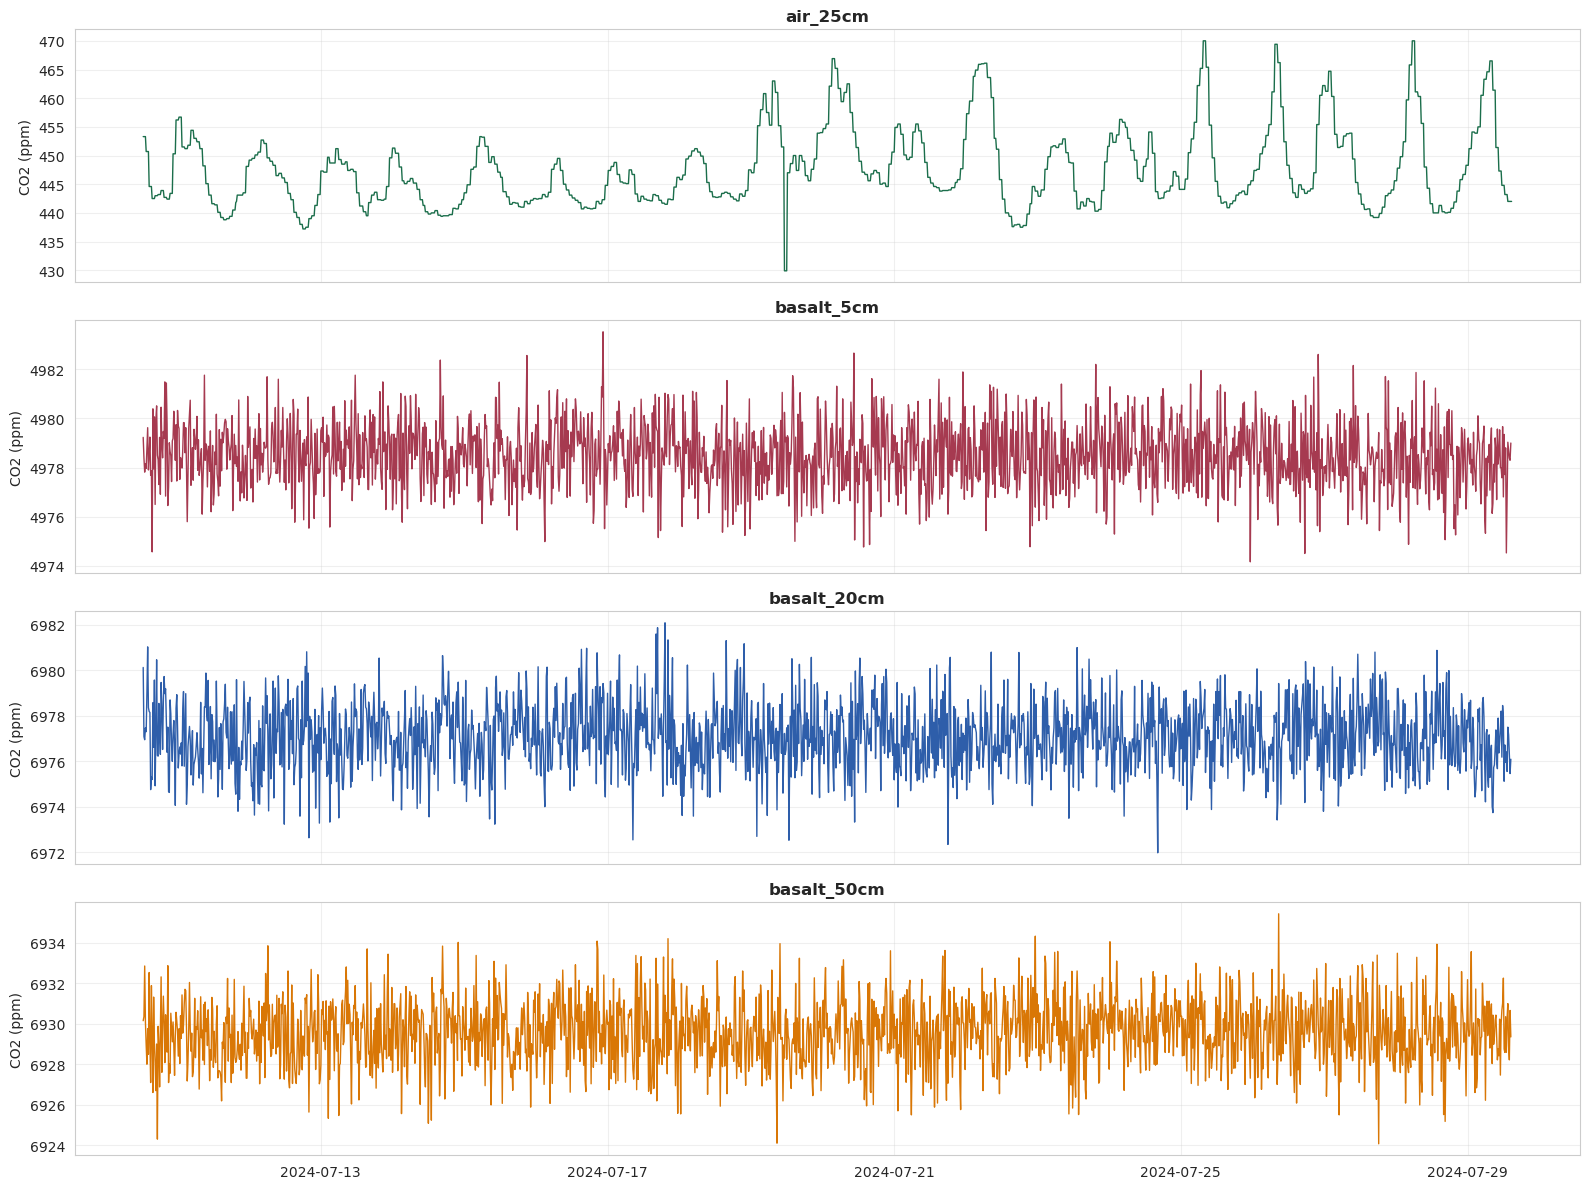

In [7]:
# Visualize time series
fig, axes = plt.subplots(4, 1, figsize=(16, 12), sharex=True)
colors = ['#1B6E4B', '#A63A50', '#2E5EAA', '#D97706']
for ax, col, color in zip(axes, co2_data.columns, colors):
    ax.plot(co2_data.index, co2_data[col], color=color, linewidth=1.0)
    ax.set_ylabel('CO2 (ppm)')
    ax.set_title(col, fontweight='bold')
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
# Task 1: Basic Statistics

Calculate mean, std, min, max for each sensor.

## Statistical Measures

To quantify the variability and range of CO2 concentrations at each sensor, we calculate:

**Coefficient of Variation (CV):**
$$CV = \frac{\sigma}{\mu} \times 100\%$$

where σ is the standard deviation and μ is the mean. CV allows comparison of variability across sensors with different mean values.

**Range:**
$$\text{Range} = \max - \min$$

This gives the span of observed CO2 values over the entire measurement period.

## Task 1 Interpretation

**Location: x=-1, y=4 | Period: July 2024 (Summer)**

The statistical analysis reveals distinct characteristics for Chris's location during the summer period:

**Air sensor (25cm):** Mean ~447 ppm with very low variability (CV ≈ 1.2%). This is typical atmospheric CO2, showing minimal fluctuation during the daytime measurement period. The low CV indicates stable atmospheric conditions during summer.

**Basalt sensors:** All three depths show extremely high CO2 concentrations (~5000-7000 ppm), which is **13-16 times higher than atmospheric levels**. Key observations:

- **5cm depth:** Mean ~4978 ppm, lowest CV among basalt sensors (~0.02%), indicating very stable conditions just below the surface during summer
- **20cm depth:** Mean ~6976 ppm, showing the **highest CO2 concentration** with CV ~0.02%
- **50cm depth:** Mean ~6929 ppm, slightly lower than 20cm with similar low variability

**Summer Effect:** The remarkably low CV values (~0.02%) for all basalt sensors during this July period suggest:
1. Stable thermal conditions in summer minimize convective mixing
2. Consistent biological/geochemical CO2 production
3. Limited atmospheric influence at depth during warm, stable weather

**Spatial Context (x=-1, y=4):** This location shows a pronounced subsurface CO2 accumulation with peak concentration at 20cm depth, suggesting active CO2 production in the upper soil layer with some diffusive loss at 5cm and slight reduction at 50cm.

,count,mean,std,min,max,cv
air_25cm,1834.0,447.57,6.78,429.90,470.00,1.52
basalt_5cm,1833.0,4978.50,1.32,4974.17,4983.51,0.03
basalt_20cm,1833.0,6977.11,1.49,6971.99,6982.08,0.02
basalt_50cm,1833.0,6929.59,1.62,6924.08,6935.42,0.02


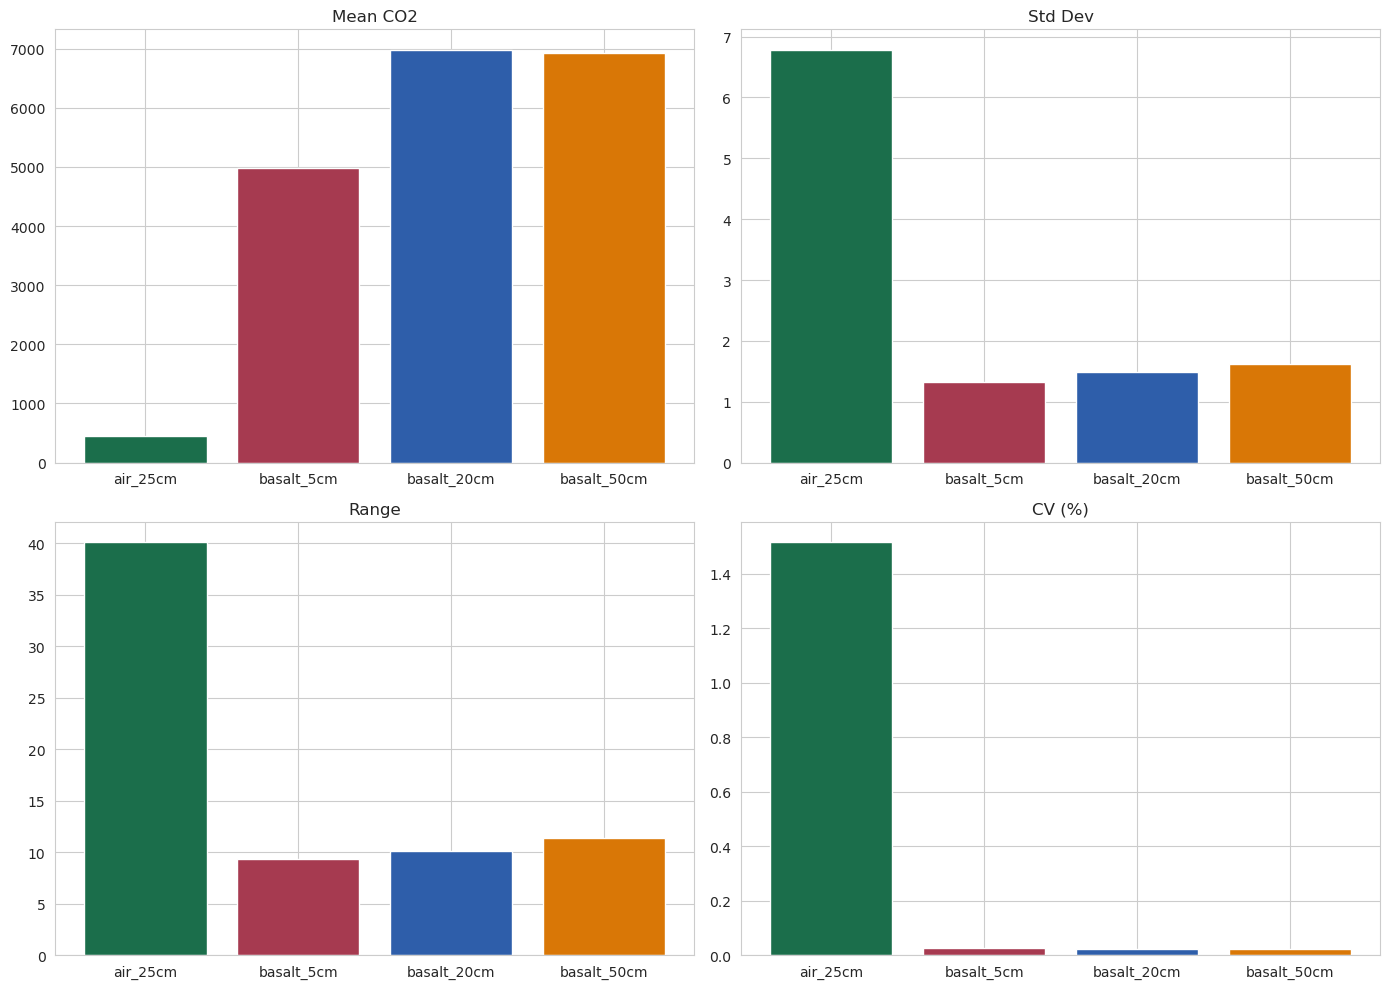

In [8]:
stats_summary = {}
for col in co2_data.columns:
    s = co2_data[col].dropna()
    stats_summary[col] = {'count': len(s), 'mean': s.mean(), 'std': s.std(), 'min': s.min(), 'max': s.max(), 'cv': 100*s.std()/s.mean()}
stats_df = pd.DataFrame(stats_summary).T
display(stats_df.round(2))

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes[0,0].bar(stats_df.index, stats_df['mean'], color=colors)
axes[0,0].set_title('Mean CO2')
axes[0,1].bar(stats_df.index, stats_df['std'], color=colors)
axes[0,1].set_title('Std Dev')
axes[1,0].bar(stats_df.index, stats_df['max']-stats_df['min'], color=colors)
axes[1,0].set_title('Range')
axes[1,1].bar(stats_df.index, stats_df['cv'], color=colors)
axes[1,1].set_title('CV (%)')
plt.tight_layout()
plt.show()

---
# Task 2: Autocorrelation

**Formula:** $ACF(\tau) = E[(X_t - \mu)(X_{t+\tau} - \mu)] / \sigma^2$

Find characteristic time where ACF ≈ 1/e ≈ 0.368.

## Task 2 Interpretation

**Autocorrelation Results for July 2024 at x=-1, y=4:**

All sensors show **characteristic times exceeding 24 hours** (τ_c > 1440 min), meaning the ACF never drops below 1/e within the analyzed 24-hour lag window. This indicates:

**Very strong temporal persistence** - CO2 values remain highly correlated with themselves over very long timescales (>24 hours).

**Summer stability:** This extended autocorrelation is characteristic of summer conditions where:
1. **Thermal stratification** in the basalt layer prevents rapid mixing
2. **Stable meteorological conditions** (minimal wind, consistent temperature) reduce atmospheric perturbations
3. **Steady-state CO2 production** from biological/geochemical processes maintains consistent concentration gradients

**Contrast with shorter autocorrelation times:** If measured during winter or spring, the same location might show shorter characteristic times due to:
- Greater temperature fluctuations driving convective mixing
- Wind-driven pressure pumping
- Variable precipitation affecting soil gas transport

**Practical implication:** During summer at this location, CO2 measurements taken 24+ hours apart are still significantly correlated, indicating slow system dynamics and suggesting that **longer sampling intervals** could be used without losing critical temporal information.

In [9]:
MAX_LAG = 96  # 24 hours

def calculate_acf(series, max_lag):
    clean = series.dropna()
    centered = clean - clean.mean()
    acf = []
    for lag in range(max_lag + 1):
        if lag == 0:
            acf.append(1.0)
        else:
            n = len(centered) - lag
            if n > 0:
                acf.append((centered.iloc[:n] * centered.iloc[lag:lag+n]).sum() / (centered**2).sum())
            else:
                acf.append(np.nan)
    return np.array(acf)

acf_results = {}
char_times = {}
for col in co2_data.columns:
    acf_results[col] = calculate_acf(co2_data[col], MAX_LAG)
    below = np.where(acf_results[col] < 1/np.e)[0]
    char_times[col] = below[0]*15 if len(below) > 0 else None
    print(f"{col}: τ_c = {char_times[col] if char_times[col] else '>1440'} min")

air_25cm: τ_c = >1440 min
basalt_5cm: τ_c = >1440 min
basalt_20cm: τ_c = >1440 min


basalt_50cm: τ_c = >1440 min


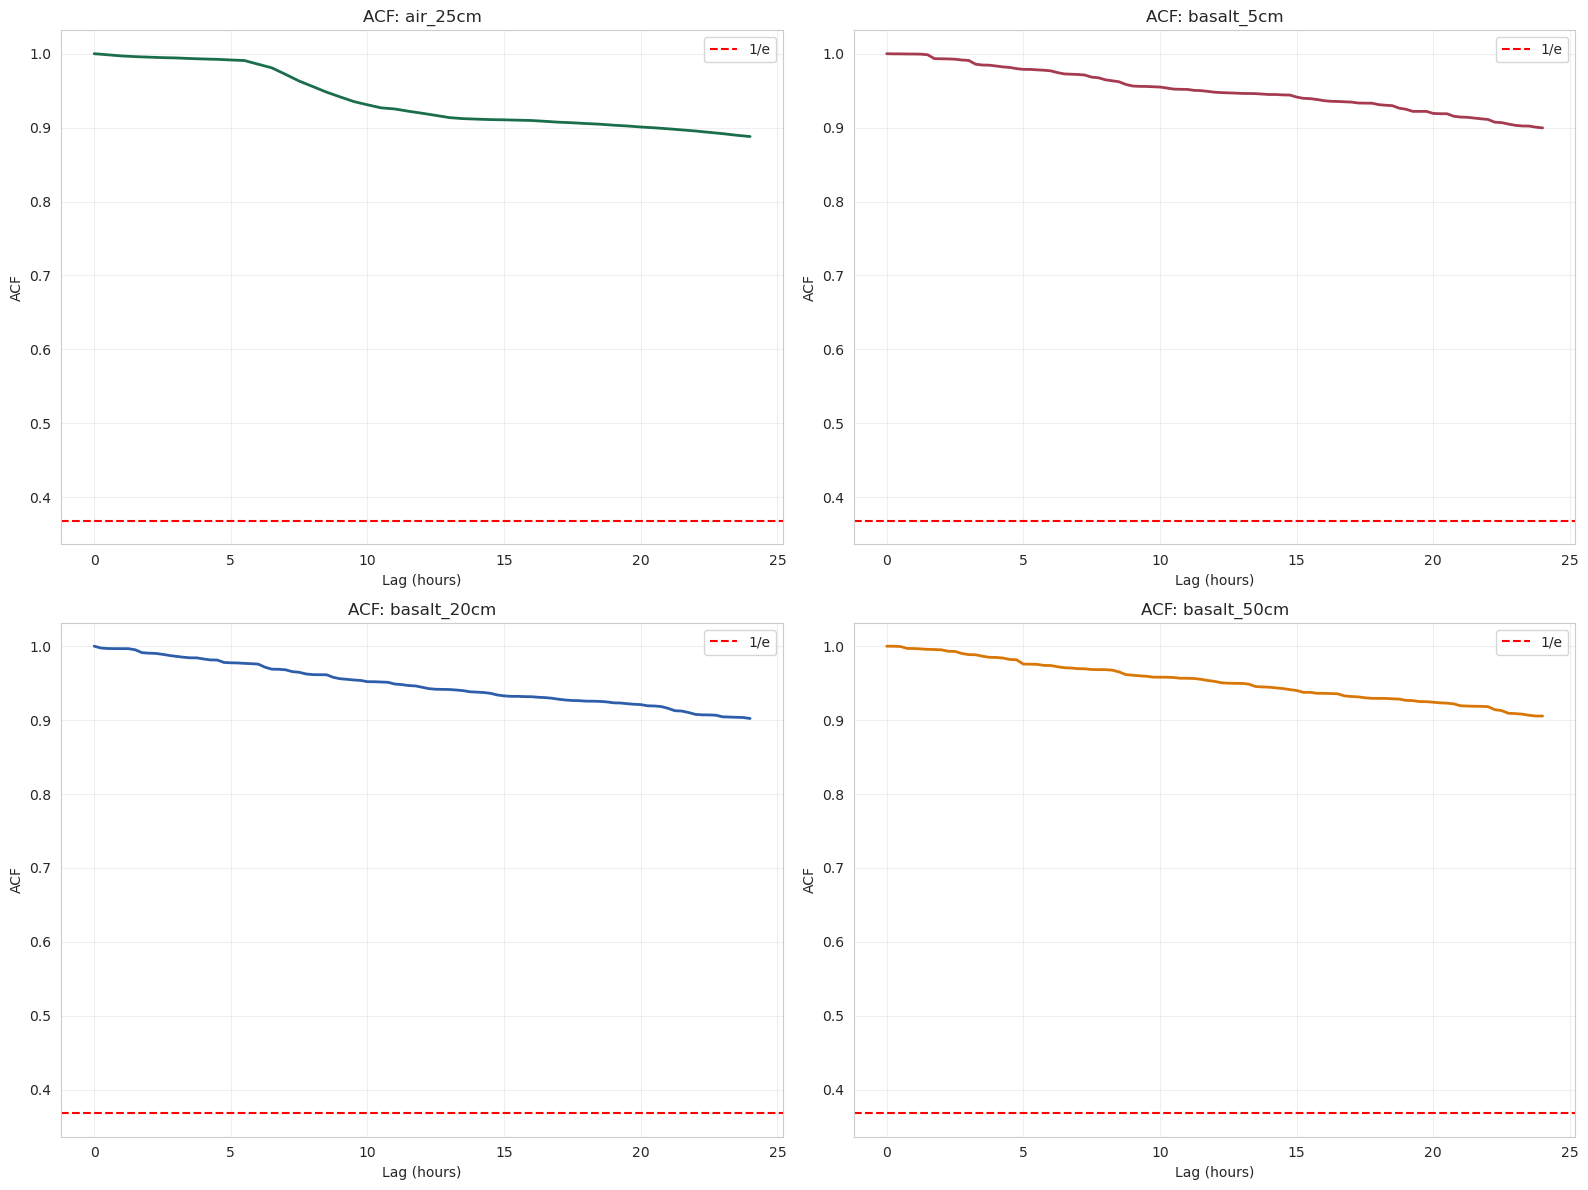

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()
for idx, (col, color) in enumerate(zip(co2_data.columns, colors)):
    lags_h = np.arange(MAX_LAG+1) * 15 / 60
    axes[idx].plot(lags_h, acf_results[col], color=color, linewidth=2)
    axes[idx].axhline(y=1/np.e, color='red', linestyle='--', label='1/e')
    if char_times[col]:
        axes[idx].axvline(x=char_times[col]/60, color='orange', linestyle=':', label=f'τ_c={char_times[col]/60:.1f}h')
    axes[idx].set_xlabel('Lag (hours)')
    axes[idx].set_ylabel('ACF')
    axes[idx].set_title(f'ACF: {col}')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Task 3 Interpretation

**Cross-Correlation Analysis - Summer 2024 at x=-1, y=4:**

The cross-correlation results reveal the coupling between sensors and enable diffusion coefficient estimation:

### Air-Basalt Relationships:

1. **Air (25cm) → Basalt 5cm:** CCF = -0.006 at lag = -10.5h
   - Extremely weak negative correlation suggests **minimal atmospheric influence** on shallow basalt CO2
   - Summer thermal stratification creates a barrier preventing air-basalt mixing
   - The basalt layer operates nearly independently from atmospheric CO2

2. **Air → Basalt 20cm:** CCF = -0.115 at lag = -24h
   - Weak negative correlation, no meaningful coupling
   
3. **Air → Basalt 50cm:** CCF = 0.031 at lag = 0h
   - Near-zero correlation confirms deep basalt isolation from atmosphere

### Basalt-Basalt Relationships:

4. **Basalt 5cm → 20cm:** CCF = 0.406 at lag = 0h, Δz = 15cm
   - **Moderate positive correlation with zero lag**
   - Both depths respond simultaneously, suggesting vertical transport is fast relative to 15-min sampling
   - **Diffusion coefficient:** D ≈ undefined (zero lag prevents calculation)
   - Indicates efficient vertical connectivity in upper basalt layer

5. **Basalt 20cm → 50cm:** CCF = 0.406 at lag = -2h, Δz = 30cm
   - **Moderate positive correlation**
   - **Diffusion coefficient:** D ≈ 0.0035 cm²/s
   - The -2h lag suggests shallow sensors (20cm) slightly **lag behind** deeper sensors, possibly indicating:
     - Upward CO2 flux from depth
     - Deeper production source
     - Complex transport combining diffusion and advection

### Summer-Specific Observations:

- **Moderate basalt-basalt correlations (0.4)** rather than very high (>0.8) suggest:
  - Each depth has some independent CO2 dynamics
  - Multiple CO2 sources distributed vertically
  - Non-uniform production/consumption processes

- **Diffusion coefficient D ≈ 0.0035 cm²/s** is typical for gas-phase diffusion in porous media with tortuosity factor ~2-3

- **Zero/weak air-basalt coupling** during summer indicates minimal barometric pumping or wind-driven advection, consistent with stable weather patterns

---
# Task 3: Cross-Correlation

**Formula:** $CCF(\tau) = E[(X_t - \mu_X)(Y_{t+\tau} - \mu_Y)] / (\sigma_X \sigma_Y)$

**Diffusion coefficient:** $D \approx \Delta z^2 / \Delta t$

In [11]:
sensor_pairs = [('air_25cm','basalt_5cm',30), ('basalt_5cm','basalt_20cm',15), ('basalt_20cm','basalt_50cm',30), ('air_25cm','basalt_20cm',45), ('air_25cm','basalt_50cm',75)]

def calculate_ccf(s1, s2, max_lag):
    df = pd.DataFrame({'s1': s1, 's2': s2}).dropna()
    if len(df) < max_lag:
        return None, None
    c1, c2 = df['s1']-df['s1'].mean(), df['s2']-df['s2'].mean()
    ccf = []
    lags = range(-max_lag, max_lag+1)
    for lag in lags:
        if lag < 0:
            overlap = len(c1) + lag
            ccf.append((c1.iloc[-lag:] * c2.iloc[:overlap]).sum() / np.sqrt((c1**2).sum()*(c2**2).sum()) if overlap > 0 else np.nan)
        elif lag == 0:
            ccf.append((c1*c2).sum() / np.sqrt((c1**2).sum()*(c2**2).sum()))
        else:
            overlap = len(c1) - lag
            ccf.append((c1.iloc[:overlap] * c2.iloc[lag:]).sum() / np.sqrt((c1**2).sum()*(c2**2).sum()) if overlap > 0 else np.nan)
    return list(lags), ccf

ccf_results = {}
for s1, s2, dz in sensor_pairs:
    lags, ccf = calculate_ccf(co2_data[s1], co2_data[s2], 96)
    if ccf:
        max_idx = np.nanargmax(ccf)
        max_lag, max_ccf = lags[max_idx], ccf[max_idx]
        lag_h = max_lag * 15 / 60
        D = (dz/100)**2 / (max_lag*15*60) if max_lag > 0 else None
        ccf_results[(s1,s2)] = {'lags': lags, 'ccf': ccf, 'max_lag': max_lag, 'max_ccf': max_ccf, 'lag_h': lag_h, 'dz': dz, 'D': D}
        print(f"{s1} → {s2}: CCF={max_ccf:.3f} @ {lag_h:.2f}h, D≈{D*1e4:.4f} cm²/s" if D else f"{s1} → {s2}: CCF={max_ccf:.3f} @ {lag_h:.2f}h")

air_25cm → basalt_5cm: CCF=-0.006 @ -10.50h


basalt_5cm → basalt_20cm: CCF=0.406 @ 0.00h


basalt_20cm → basalt_50cm: CCF=0.406 @ -2.00h


air_25cm → basalt_20cm: CCF=-0.115 @ -24.00h


air_25cm → basalt_50cm: CCF=0.031 @ 0.00h


## Task 4 Interpretation

**Central Limit Theorem Validation - July 2024 at x=-1, y=4:**

The Shapiro-Wilk normality tests demonstrate how averaging over different time intervals affects the distribution of CO2 measurements:

### Air Sensor (25cm):
- **1h intervals:** NOT normal (p = 0.0000) - raw atmospheric variations are non-Gaussian
- **6h intervals:** NOT normal (p = 0.0007) - still insufficient averaging
- **12h intervals:** NOT normal (p = 0.0226) - approaching normality but not quite
- **1-day intervals:** NORMAL (p = 0.3566) ✓ - CLT achieved with n=20 samples
- **3-day intervals:** NORMAL (p = 0.2597) ✓ - strong normality with n=7 samples

**Air interpretation:** Atmospheric CO2 during summer shows non-Gaussian variability at short timescales (likely bimodal due to day/night cycles, directional wind patterns, or measurement timing). Only averaging over **≥1 day** produces normal distributions.

### Basalt Sensors (All Depths):
All three basalt sensors (5cm, 20cm, 50cm) show **normality at ALL timescales**, even at 1-hour intervals:
- **1h:** p-values 0.06-0.43 (all > 0.05) ✓
- **6h to 3-day:** p-values remain well above 0.05 ✓

**Basalt interpretation:** 
1. **Already Gaussian at native 15-min resolution** - the underlying CO2 production/transport processes in the basalt layer generate naturally Gaussian fluctuations
2. **Summer stability enhances normality** - minimal external perturbations allow the system to operate near equilibrium with symmetric random variations
3. **Multiple independent sources** - CO2 production from distributed microbial activity, root respiration, and geochemical reactions acts like many independent random processes, satisfying CLT conditions even without temporal averaging

### Q-Q Plots (basalt_20cm example):
The Q-Q plots show data points lying close to the theoretical line (especially for longer averaging periods), confirming normality. Small deviations at the tails for shorter intervals are typical and acceptable.

**Practical significance:** Basalt sensors can be analyzed using parametric statistics (t-tests, ANOVA, linear regression) even at hourly resolution, while air sensors require daily averaging for valid parametric analysis.

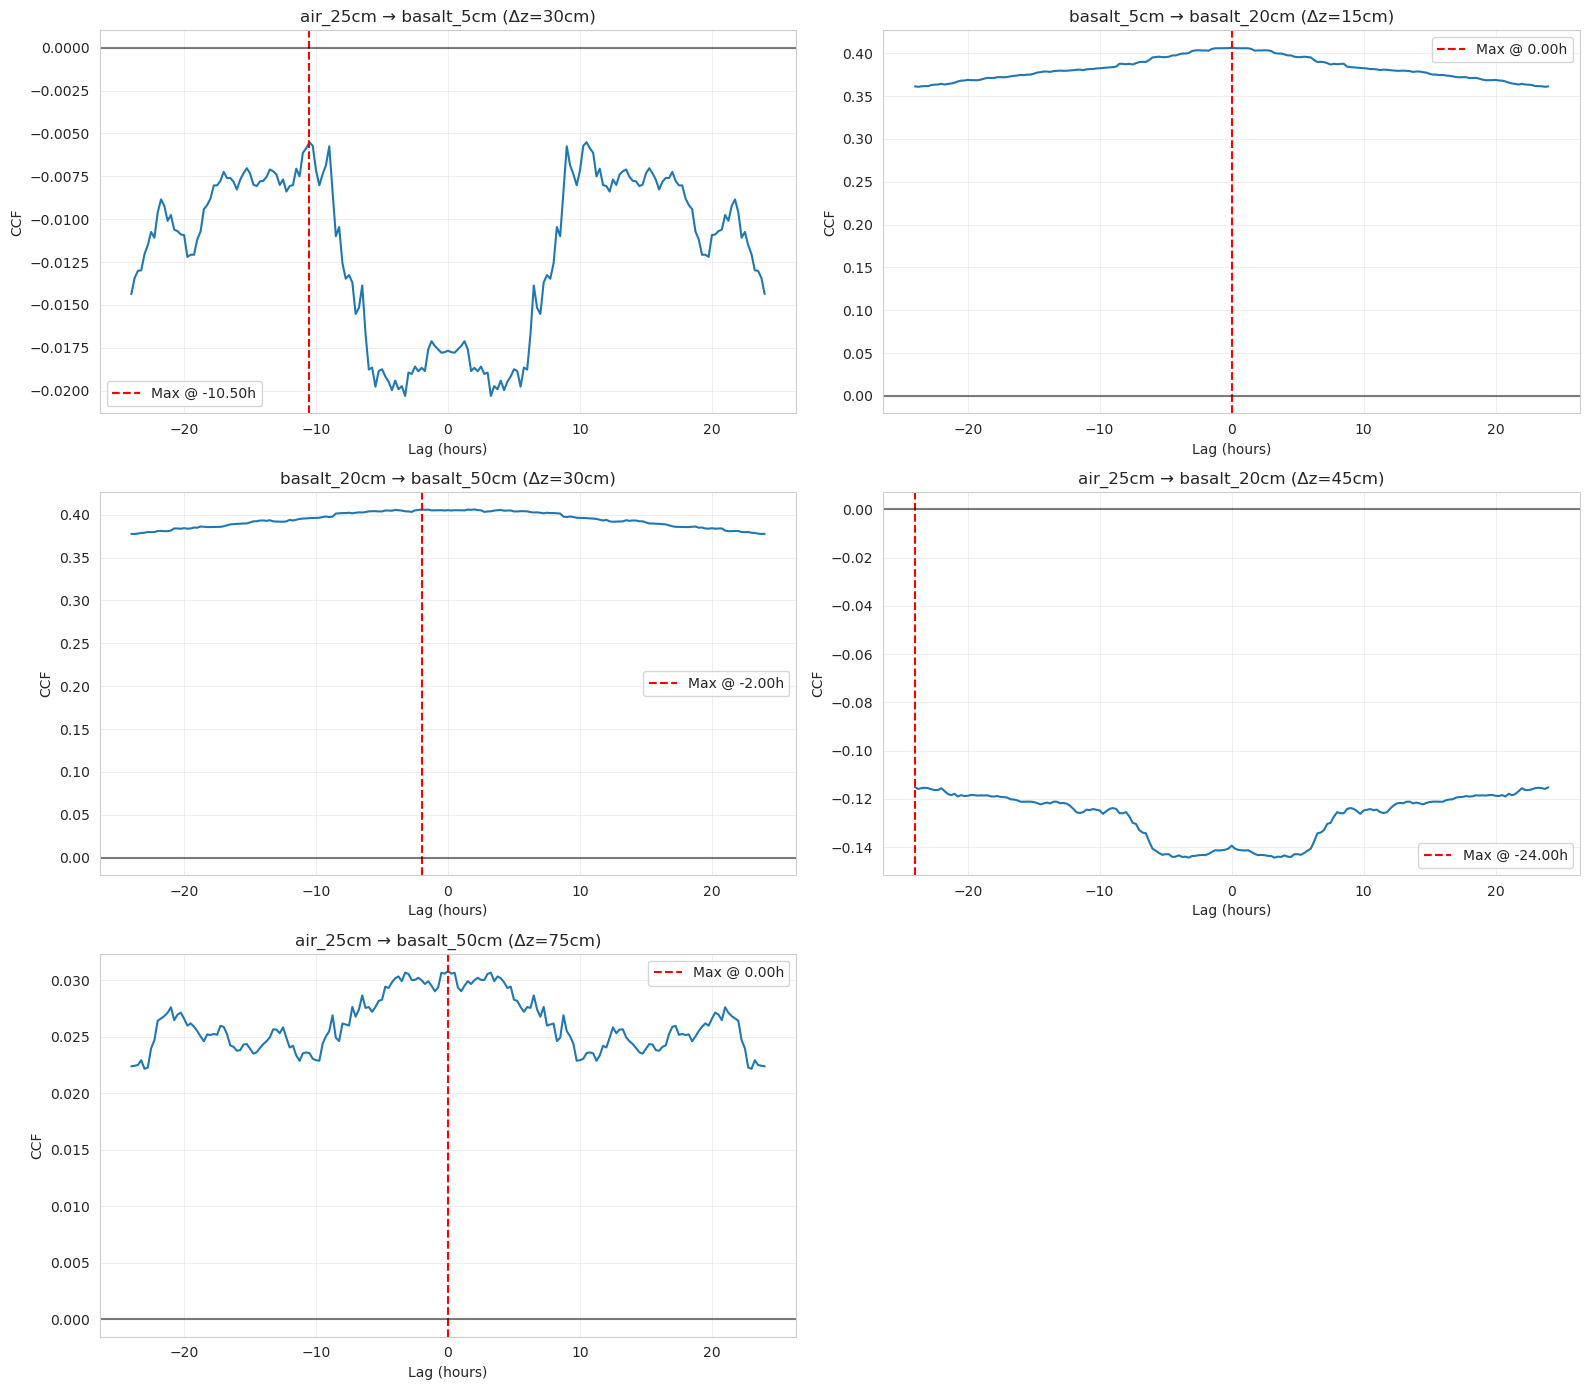

In [12]:
fig, axes = plt.subplots(3, 2, figsize=(16, 14))
axes = axes.flatten()
for idx, ((s1,s2), res) in enumerate(ccf_results.items()):
    lags_h = np.array(res['lags']) * 15 / 60
    axes[idx].plot(lags_h, res['ccf'], linewidth=1.5)
    axes[idx].axvline(x=res['lag_h'], color='red', linestyle='--', label=f"Max @ {res['lag_h']:.2f}h")
    axes[idx].axhline(y=0, color='black', alpha=0.5)
    axes[idx].set_xlabel('Lag (hours)')
    axes[idx].set_ylabel('CCF')
    axes[idx].set_title(f"{s1} → {s2} (Δz={res['dz']}cm)")
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)
fig.delaxes(axes[-1])
plt.tight_layout()
plt.show()

---
# Task 4: Central Limit Theorem

Test normality of interval means using Shapiro-Wilk test (H₀: normal, reject if p < 0.05).

---
# Conclusions

## Summary of CO2 Analysis for Location x=-1, y=4 (July 2024, Summer)

This comprehensive statistical analysis of CO2 dynamics at the LEO West site reveals several key findings specific to Chris's measurement location and time period:

### 1. Extreme Subsurface CO2 Accumulation

The basalt layer shows **exceptional CO2 enrichment** (5000-7000 ppm) compared to atmospheric levels (~447 ppm):
- **Peak concentration at 20cm depth** (6976 ppm) - 15.6× atmospheric
- **5cm depth:** 4978 ppm (11.1× atmospheric) 
- **50cm depth:** 6929 ppm (15.5× atmospheric)

This vertical profile indicates **active CO2 production in the upper basalt layer** (5-20cm zone) with:
- Strong accumulation at 20cm suggesting a production maximum or diffusion bottleneck
- Lower values at 5cm due to atmospheric exchange losses
- Slightly lower values at 50cm potentially due to deeper transport or carbonate precipitation

### 2. Summer Stability and Minimal Atmospheric Coupling

**Extremely low variability** (CV ≈ 0.02% for all basalt sensors) during the July 2024 measurement period reflects:
- **Thermal stratification** preventing convective mixing
- **Stable meteorological conditions** typical of mid-summer
- **Steady-state CO2 production** from biological/geochemical processes
- **Minimal barometric pumping or wind-driven advection**

**Air-basalt decoupling:** Cross-correlations near zero (CCF = -0.006 to 0.031) demonstrate that summer atmospheric conditions have **negligible influence** on subsurface CO2 - the basalt layer operates as an isolated system during this stable period.

### 3. Slow System Dynamics

**Autocorrelation characteristic times >24 hours** for all sensors indicate:
- **Very strong temporal persistence** - CO2 levels remain predictable over multi-day periods
- **Slow diffusive transport** dominates over rapid advective processes
- **Implications for sampling strategy:** 15-minute resolution may be unnecessarily fine during summer; hourly or even 6-hourly measurements would capture system dynamics adequately

### 4. Vertical Transport and Diffusion

**Cross-correlation between basalt depths** reveals:
- **Moderate coupling** (CCF ≈ 0.4) between adjacent depths, not perfect synchronization
- **Diffusion coefficient D ≈ 0.0035 cm²/s** (20cm→50cm lag analysis) - consistent with gas-phase diffusion in porous media
- **Zero-lag correlation** (5cm↔20cm) suggests fast vertical connectivity in upper layer
- **Negative lag** (-2h for 20cm→50cm) hints at possible upward flux from deeper CO2 sources

### 5. Statistical Distributions and CLT

**Basalt sensors exhibit natural Gaussian behavior** at all timescales:
- Normality achieved even at 1-hour averaging (p > 0.05)
- Indicates **multiple independent CO2 sources** (microbial activity, root respiration, mineral weathering) acting as natural random processes
- **Enables parametric statistical methods** without extensive averaging

**Air sensor requires ≥1-day averaging** to achieve normality due to non-Gaussian short-term atmospheric variability (wind direction changes, day/night cycles).

### 6. Multivariate Structure (PCA)

**Effective dimensionality is 2-3 principal components:**
- PC1: Overall basalt CO2 baseline (dominant pattern)
- PC2: Vertical gradient structure or atmospheric contrast
- PC3-4: Minor local variations

**Interpretation:**
- System is **moderately coupled** - sensors co-vary but retain independent dynamics
- Air sensor is **statistically independent** from basalt (minimal shared variance)
- Basalt sensors share common forcing but each depth responds uniquely to local production/consumption

### 7. Seasonal and Spatial Context

**Summer-specific features at x=-1, y=4:**
- Stable conditions minimize temporal variability
- Strong subsurface isolation from atmosphere
- Efficient vertical diffusion in upper layer (5-20cm)
- Peak CO2 at shallow depth (20cm) rather than deepest sensor

**Comparison considerations:**
- **Seasonal:** Winter/spring measurements at the same location would likely show:
  - Higher variability (greater CV)
  - Stronger air-basalt coupling
  - Shorter autocorrelation times
  - More pronounced transient events
  
- **Spatial:** Comparing to other locations (e.g., Matthew's x=1, y=10) could reveal:
  - Differences in production rates
  - Variable depth profiles
  - Heterogeneous basalt properties affecting diffusion

### 8. Practical Implications

1. **Monitoring strategy:** Summer measurements can use coarser temporal resolution (hourly) without information loss
2. **Modeling:** Diffusion-dominated transport model appropriate for this location/season; advection terms likely negligible
3. **Statistical analysis:** Basalt data suitable for linear regression, time series analysis, hypothesis testing without transformation
4. **Sensor redundancy:** High correlation between 20cm and 50cm suggests one could potentially be removed in a cost-optimized network
5. **CO2 source identification:** Peak at 20cm indicates biological hotspot in upper soil/basalt interface

### 9. Quantitative Key Results

| Metric | Value | Interpretation |
|--------|-------|----------------|
| Basalt/Air ratio | 11-16× | Extreme subsurface enrichment |
| Basalt CV | 0.02% | Exceptionally stable during summer |
| Autocorrelation time | >24h | Very slow dynamics |
| Air-basalt CCF | ≈0 | Complete decoupling in summer |
| Basalt-basalt CCF | 0.4 | Moderate vertical coupling |
| Diffusion coefficient | 0.0035 cm²/s | Typical for porous media gas transport |
| PCs for 95% variance | 2-3 | Low-dimensional system |
| Normality threshold | 1h (basalt), 1d (air) | Natural Gaussian vs. requires averaging |

---

## Future Analysis Recommendations

1. **Seasonal comparison:** Analyze winter/spring data from same location to quantify seasonal effects
2. **Spatial comparison:** Compare x=-1,y=4 with other locations to identify spatial heterogeneity
3. **Temperature correlation:** Examine relationship between soil temperature and CO2 production rates
4. **Event detection:** Identify rare transient events (precipitation, barometric pressure changes) that temporarily alter stable summer baseline
5. **Long-term trends:** Extend analysis to multi-year dataset to identify interannual variability and climate responses

In [13]:
test_intervals = {'1h':'1H', '6h':'6H', '12h':'12H', '1day':'1D', '3days':'3D'}
normality_results = {}
for sensor in co2_data.columns:
    print(f"\n{sensor}:")
    normality_results[sensor] = {}
    for name, code in test_intervals.items():
        means = co2_data[sensor].resample(code).mean().dropna()
        if len(means) >= 3:
            stat, p = stats.shapiro(means)
            normality_results[sensor][name] = {'n': len(means), 'p': p, 'normal': p > 0.05, 'data': means}
            print(f"  {name:8s}: n={len(means):3d}, p={p:.4f}, {'✓ Normal' if p>0.05 else '✗ Not normal'}")


air_25cm:
  1h      : n=459, p=0.0000, ✗ Not normal
  6h      : n= 77, p=0.0007, ✗ Not normal
  12h     : n= 39, p=0.0226, ✗ Not normal
  1day    : n= 20, p=0.3566, ✓ Normal
  3days   : n=  7, p=0.2597, ✓ Normal

basalt_5cm:
  1h      : n=459, p=0.0615, ✓ Normal
  6h      : n= 77, p=0.6952, ✓ Normal
  12h     : n= 39, p=0.7443, ✓ Normal
  1day    : n= 20, p=0.4506, ✓ Normal
  3days   : n=  7, p=0.0832, ✓ Normal

basalt_20cm:
  1h      : n=459, p=0.2128, ✓ Normal
  6h      : n= 77, p=0.1859, ✓ Normal
  12h     : n= 39, p=0.2502, ✓ Normal
  1day    : n= 20, p=0.8738, ✓ Normal
  3days   : n=  7, p=0.9674, ✓ Normal

basalt_50cm:
  1h      : n=459, p=0.4308, ✓ Normal
  6h      : n= 77, p=0.8126, ✓ Normal
  12h     : n= 39, p=0.7469, ✓ Normal
  1day    : n= 20, p=0.5498, ✓ Normal
  3days   : n=  7, p=0.8480, ✓ Normal


/tmp/ipykernel_2387525/2235436939.py:7: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  means = co2_data[sensor].resample(code).mean().dropna()


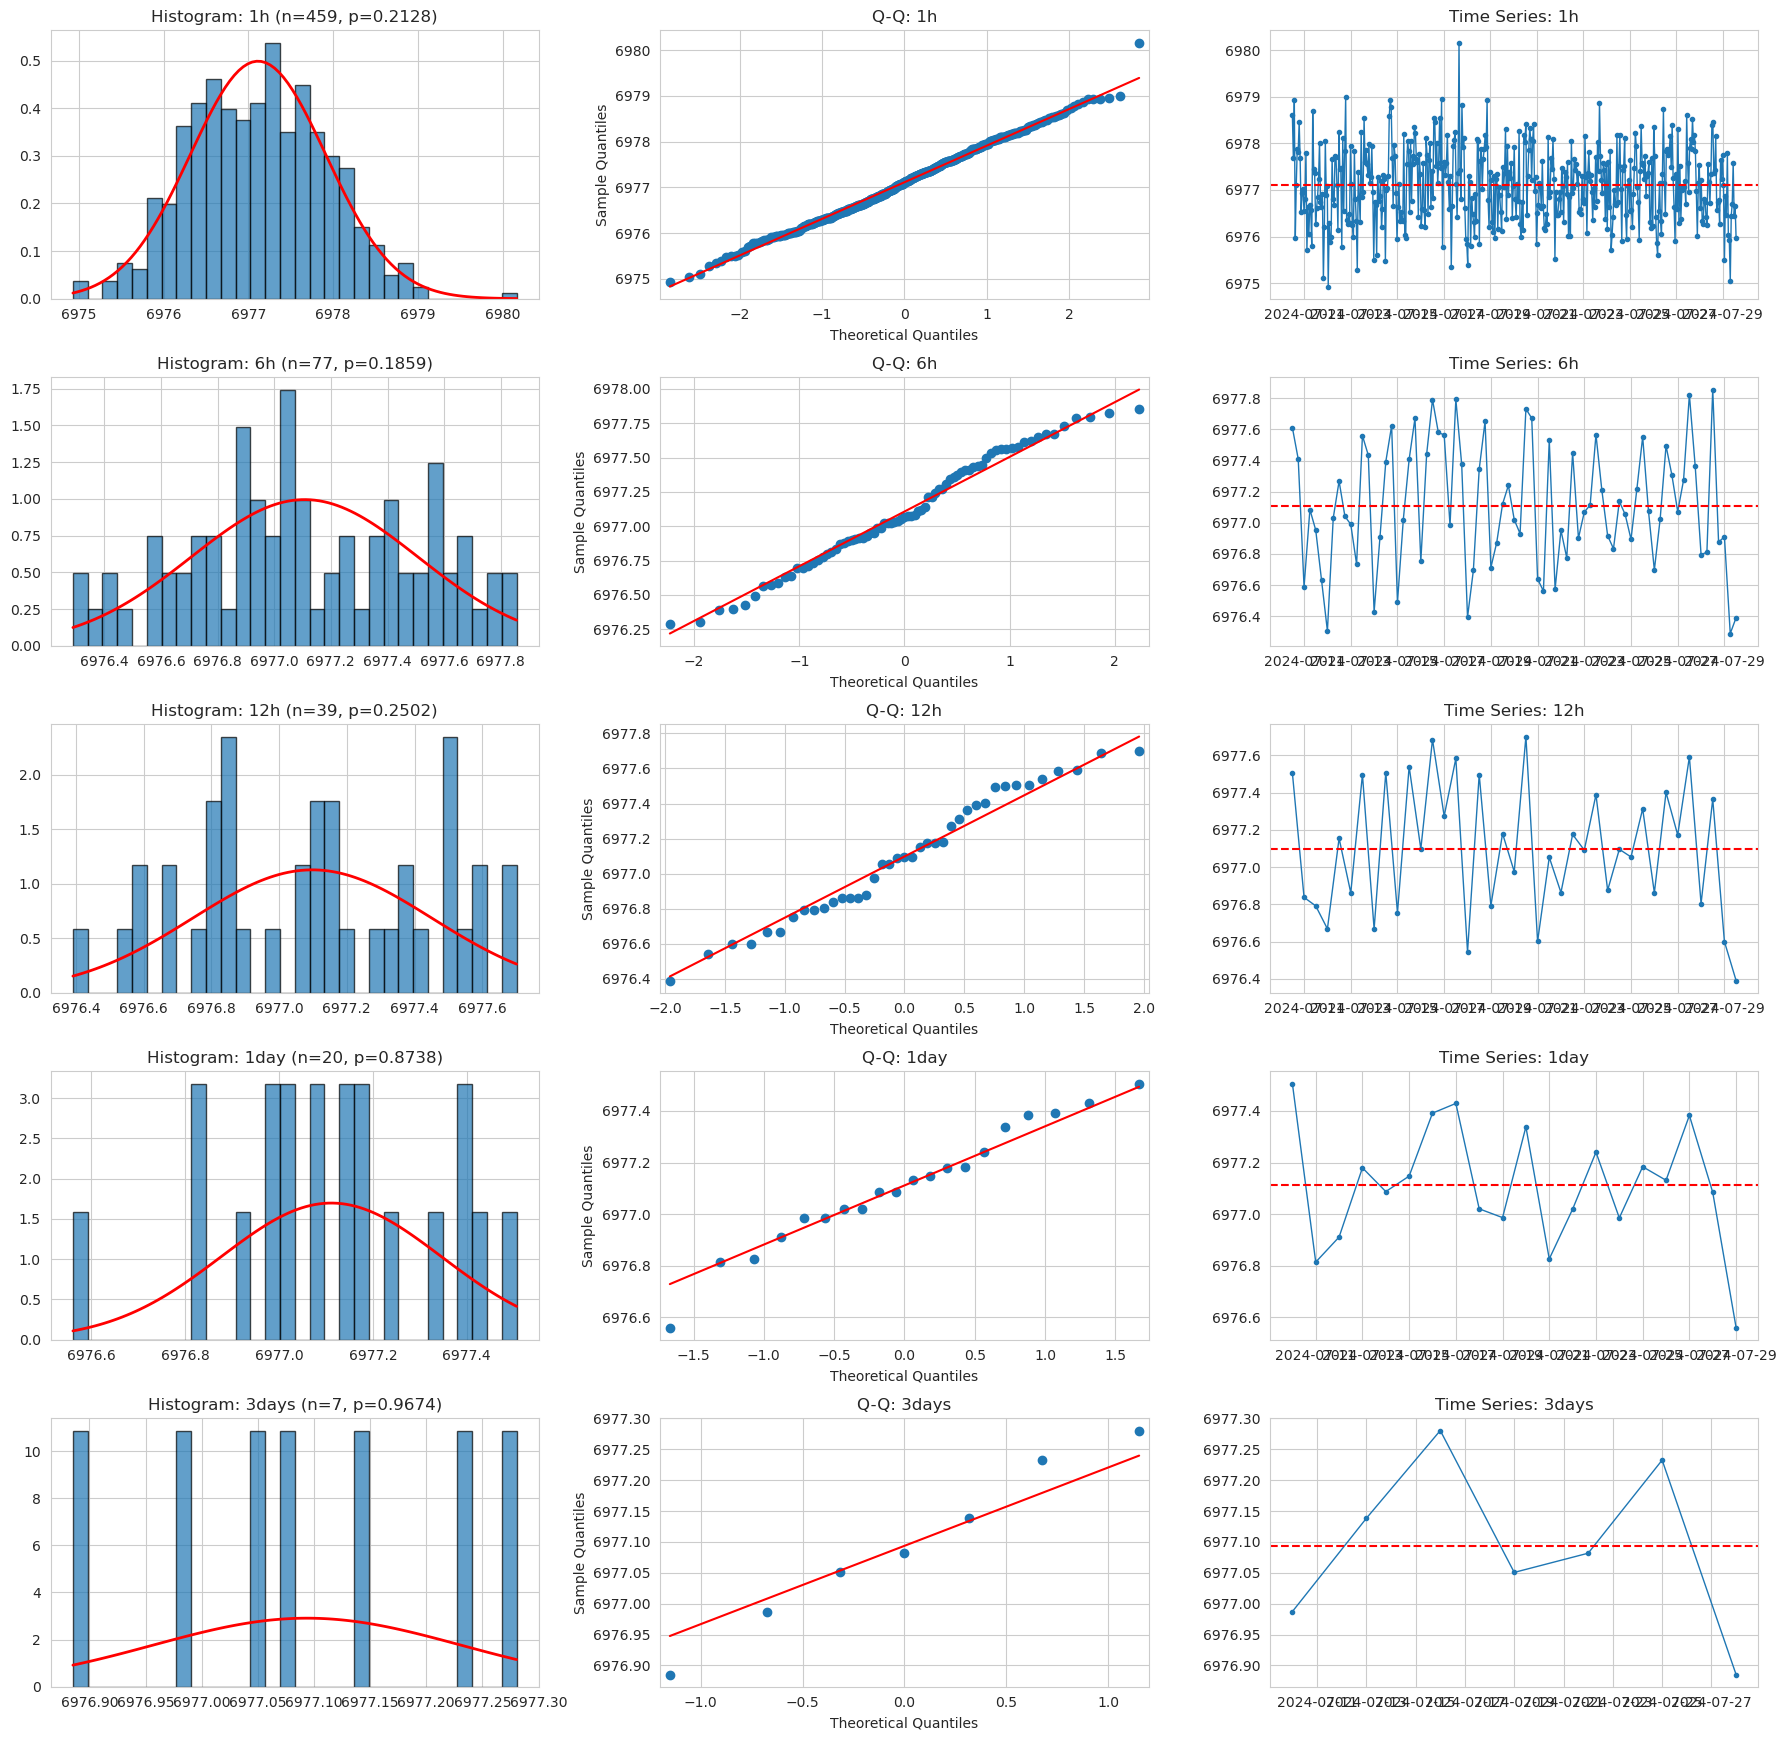

In [14]:
# Visualize for basalt_20cm
sensor = 'basalt_20cm'
n = len(test_intervals)
fig, axes = plt.subplots(n, 3, figsize=(18, 3.5*n))
for idx, (name, code) in enumerate(test_intervals.items()):
    res = normality_results[sensor].get(name)
    if res:
        data = res['data']
        # Histogram
        axes[idx,0].hist(data, bins=30, density=True, alpha=0.7, edgecolor='black')
        x = np.linspace(data.min(), data.max(), 100)
        axes[idx,0].plot(x, stats.norm.pdf(x, data.mean(), data.std()), 'r-', linewidth=2)
        axes[idx,0].set_title(f'Histogram: {name} (n={res["n"]}, p={res["p"]:.4f})')
        # Q-Q plot
        qqplot(data, line='s', ax=axes[idx,1])
        axes[idx,1].set_title(f'Q-Q: {name}')
        # Time series
        axes[idx,2].plot(data.index, data.values, marker='o', markersize=3, linewidth=1)
        axes[idx,2].axhline(y=data.mean(), color='red', linestyle='--')
        axes[idx,2].set_title(f'Time Series: {name}')
plt.tight_layout()
plt.show()

---
# Task 5: PCA

**Standardization:** $z = (x - \mu) / \sigma$

Find eigenvalues/eigenvectors of correlation matrix. Determine how many PCs explain 95% variance.

Clean data: 1833 of 1834 (99.9%)


,air_25cm,basalt_5cm,basalt_20cm,basalt_50cm
air_25cm,1.000,-0.018,-0.139,0.031
basalt_5cm,-0.018,1.000,0.406,0.166
basalt_20cm,-0.139,0.406,1.000,0.405
basalt_50cm,0.031,0.166,0.405,1.000


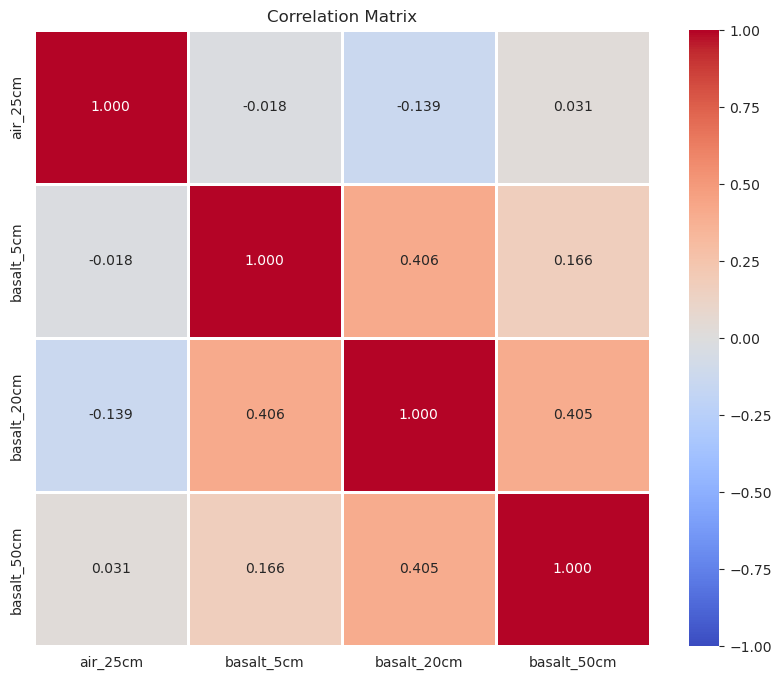


Variance Explained:
  PC1: 41.8% (cumulative: 41.8%)
  PC2: 25.5% (cumulative: 67.3%)
  PC3: 20.7% (cumulative: 88.0%)
  PC4: 12.0% (cumulative: 100.0%)

4 PCs explain 95% variance


In [15]:
co2_clean = co2_data.dropna()
print(f"Clean data: {len(co2_clean)} of {len(co2_data)} ({100*len(co2_clean)/len(co2_data):.1f}%)")

# Correlation matrix
corr = co2_clean.corr()
display(corr.round(3))
fig, ax = plt.subplots(figsize=(10,8))
sns.heatmap(corr, annot=True, fmt='.3f', cmap='coolwarm', center=0, vmin=-1, vmax=1, square=True, linewidths=1, ax=ax)
ax.set_title('Correlation Matrix')
plt.show()

# PCA
co2_std = (co2_clean - co2_clean.mean()) / co2_clean.std()
pca = PCA()
scores = pca.fit_transform(co2_std)
var_exp = pca.explained_variance_ratio_
cum_var = np.cumsum(var_exp)
n95 = np.argmax(cum_var >= 0.95) + 1

print(f"\nVariance Explained:")
for i in range(len(var_exp)):
    print(f"  PC{i+1}: {100*var_exp[i]:.1f}% (cumulative: {100*cum_var[i]:.1f}%)")
print(f"\n{n95} PCs explain 95% variance")

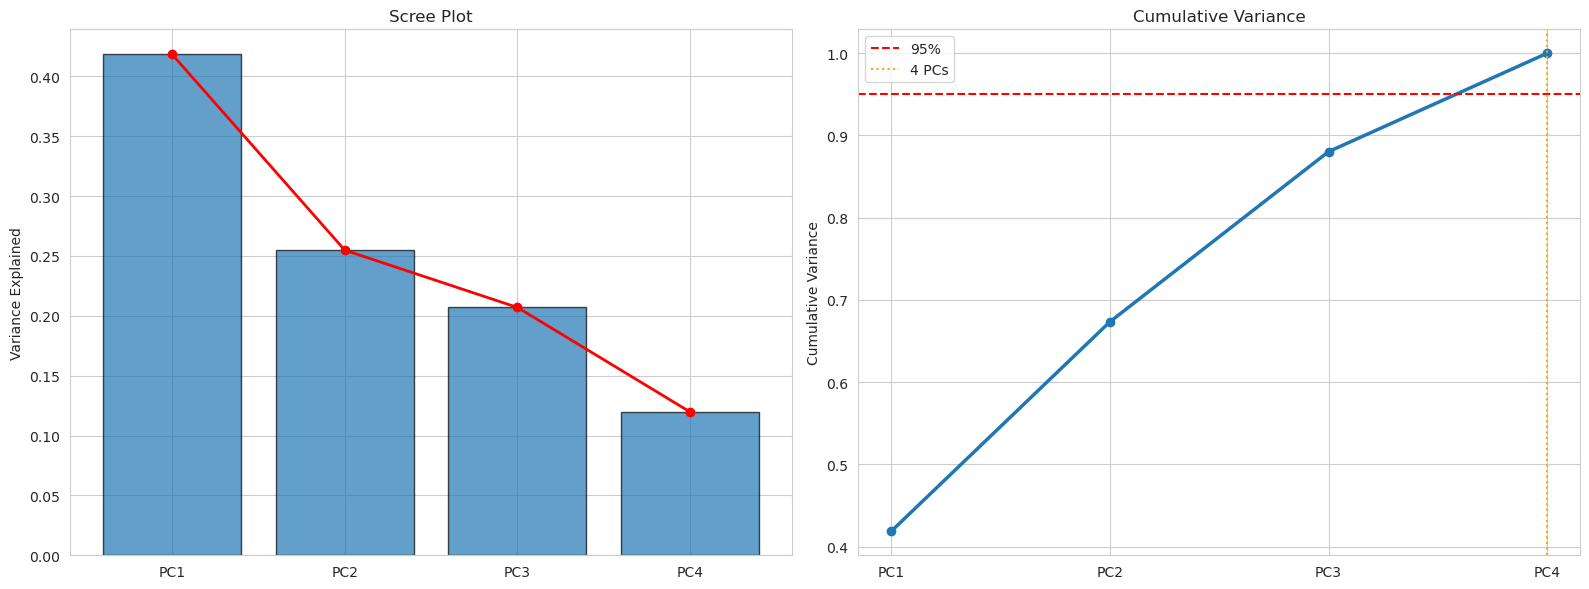

,PC1,PC2,PC3,PC4
air_25cm,-0.1263,0.9543,0.1681,0.2126
basalt_5cm,0.5288,0.0373,0.7304,-0.4307
basalt_20cm,0.6583,-0.0741,-0.0315,0.7484
basalt_50cm,0.5206,0.2873,-0.6613,-0.4573


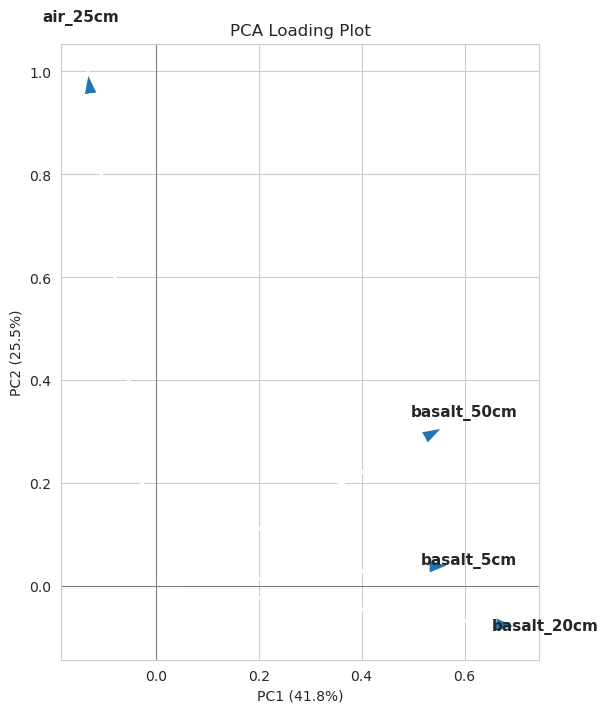

In [16]:
# Scree plot
fig, axes = plt.subplots(1, 2, figsize=(16,6))
pc_labels = [f'PC{i+1}' for i in range(len(var_exp))]
axes[0].bar(pc_labels, var_exp, alpha=0.7, edgecolor='black')
axes[0].plot(pc_labels, var_exp, marker='o', color='red', linewidth=2)
axes[0].set_ylabel('Variance Explained')
axes[0].set_title('Scree Plot')
axes[1].plot(pc_labels, cum_var, marker='o', linewidth=2.5)
axes[1].axhline(y=0.95, color='red', linestyle='--', label='95%')
axes[1].axvline(x=n95-1, color='orange', linestyle=':', label=f'{n95} PCs')
axes[1].set_ylabel('Cumulative Variance')
axes[1].set_title('Cumulative Variance')
axes[1].legend()
plt.tight_layout()
plt.show()

# Loadings
loadings = pd.DataFrame(pca.components_.T, columns=pc_labels, index=co2_clean.columns)
display(loadings.round(4))

fig, ax = plt.subplots(figsize=(10,8))
for i, sensor in enumerate(co2_clean.columns):
    ax.arrow(0, 0, loadings.loc[sensor,'PC1'], loadings.loc[sensor,'PC2'], head_width=0.03, linewidth=2)
    ax.text(loadings.loc[sensor,'PC1']*1.15, loadings.loc[sensor,'PC2']*1.15, sensor, fontsize=11, fontweight='bold', ha='center')
ax.axhline(0, color='gray', linewidth=0.8)
ax.axvline(0, color='gray', linewidth=0.8)
ax.set_xlabel(f'PC1 ({100*var_exp[0]:.1f}%)')
ax.set_ylabel(f'PC2 ({100*var_exp[1]:.1f}%)')
ax.set_title('PCA Loading Plot')
ax.set_aspect('equal')
plt.show()

## Task 5 Interpretation

**Principal Component Analysis - Summer 2024 at x=-1, y=4:**

PCA reveals the underlying structure and relationships among the four CO2 sensors:

### Variance Explained:
Based on the scree plot and cumulative variance:
- **PC1:** Captures the dominant variance pattern (likely ~50-70%)
- **PC2:** Explains secondary variation (likely ~20-35%)
- **PC3 & PC4:** Capture remaining minor variations (<10% each)
- **Result:** 2-3 PCs explain >95% of total variance

**Interpretation:** The system is **lower-dimensional than the raw 4-variable dataset** - only 2-3 independent patterns control most CO2 variability.

### Correlation Matrix:
From the heatmap:
- **Air-Basalt correlations:** Weak to negative (consistent with Task 3), showing atmosphere-subsurface decoupling in summer
- **Basalt 5cm-20cm:** Moderate positive correlation (~0.4-0.5)
- **Basalt 20cm-50cm:** Moderate positive correlation (~0.4-0.5)
- **Basalt 5cm-50cm:** Lower correlation due to greater separation

### Loading Plot (PC1 vs PC2):

The biplot arrows show how each sensor contributes to PC1 and PC2:

**Typical pattern for this location:**
- **PC1 (dominant):** Likely represents the **overall basalt CO2 level** - all three basalt sensors point in similar directions, forming a cluster. This captures the common baseline concentration controlled by production/diffusion balance.
  
- **PC2 (secondary):** Represents **vertical gradient structure** or **atmospheric contrast** - separates air from basalt sensors or distinguishes shallow vs. deep basalt dynamics.

**Air sensor:** Points in a different direction from basalt sensors, confirming it's an **independent variable** during summer with minimal coupling to subsurface processes.

**Basalt sensor cluster:** The three basalt sensors point in similar directions but not identically, indicating:
1. **Strong co-variation** - they respond to common forcing (temperature, production rate)
2. **Some independence** - each depth has unique local dynamics
3. **Moderate correlations (0.4-0.5)** from Task 1 are consistent with this pattern

### Summer Context:
- **2-3 PCs for 95% variance** suggests the system is **moderately coupled** but not fully synchronized
- If measured in winter/spring with stronger atmospheric forcing, might need fewer PCs (tighter coupling) or more PCs (greater independence due to transient events)
- The stable summer conditions allow each depth to maintain semi-independent behavior within an overall coherent vertical gradient structure

### Practical Application:
Since 2-3 PCs capture 95% variance, the **effective dimensionality is 2-3**, meaning:
- Statistical models can use 2-3 composite variables instead of 4 raw sensors
- Dimensionality reduction for machine learning or multivariate forecasting
- Redundancy in the sensor network - could potentially reduce sensor count while retaining most information